# 🎯 Affine Transformations in OpenCV - Complete Guide

## 📚 What You'll Learn

In this notebook, you will master:
- ✅ What affine transformations are
- ✅ How to rotate, scale, translate, and shear images
- ✅ Difference between affine and perspective transforms
- ✅ Real-world applications (image alignment, data augmentation)
- ✅ Hands-on examples with detailed explanations

---

## 🧠 Theory: What is Affine Transformation?

An **affine transformation** is a geometric operation that:

### Preserves:
- **Straight lines** (lines remain lines, not curves)
- **Parallelism** (parallel lines stay parallel)
- **Ratios of distances** along lines

### Allows:
- **Rotation** - Turn the image
- **Scaling** - Make it bigger/smaller
- **Translation** - Move it around
- **Shearing** - Skew/slant the image

### Key Formula:
Where:
- `(x, y)` = original point
- `(x', y')` = transformed point
- `a, b, c, d` = transformation parameters
- `tx, ty` = translation (shift)

---

## 🔑 Key Difference

| Transform Type | Points Needed | Preserves | Use Case |
|---------------|---------------|-----------|----------|
| **Affine** | 3 points | Parallel lines | Rotation, scaling, shear |
| **Perspective** | 4 points | Vanishing points | Document scanning, 3D effects |

---

## 📦 Let's Start!

In [1]:
# ============================================
# IMPORT LIBRARIES
# ============================================

import cv2                    # OpenCV for image processing
import numpy as np            # NumPy for numerical operations
import matplotlib.pyplot as plt  # Matplotlib for displaying images

# Configure matplotlib to display images inline in notebook
%matplotlib inline

# Set default figure size for better visibility
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ All libraries imported successfully!")
print(f"OpenCV version: {cv2.__version__}")
print(f"NumPy version: {np.__version__}")

✅ All libraries imported successfully!
OpenCV version: 5.0.0
NumPy version: 2.5.1


In [2]:
# ============================================
# HELPER FUNCTION: Display Multiple Images
# ============================================

def show_images(images, titles, figsize=(15, 5), cmap=None):
    """
    Display multiple images side by side in a single row.
    
    Parameters:
    -----------
    images : list
        List of images to display (numpy arrays)
    titles : list
        List of titles for each image
    figsize : tuple, optional
        Figure size as (width, height). Default is (15, 5)
    cmap : str, optional
        Colormap for grayscale images. Use 'gray' for grayscale
    
    Example:
    --------
    show_images([img1, img2], ['Original', 'Transformed'])
    """
    n = len(images)
    plt.figure(figsize=figsize)
    
    for i in range(n):
        plt.subplot(1, n, i + 1)
        
        # Check if image is color (3 channels) or grayscale
        if len(images[i].shape) == 3:
            # Convert BGR to RGB for proper color display
            plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
        else:
            # Display grayscale image
            plt.imshow(images[i], cmap='gray')
        
        plt.title(titles[i], fontsize=12, fontweight='bold')
        plt.axis('off')  # Hide axes
    
    plt.tight_layout()
    plt.show()

print("✅ Helper function created!")

✅ Helper function created!


---

## 🖼️ Step 1: Create a Sample Image

We'll create a simple image with geometric shapes to clearly see the transformations.

### Alternative:
If you have your own image, replace the code below with:
```python
img = cv2.imread('path/to/your/image.jpg')

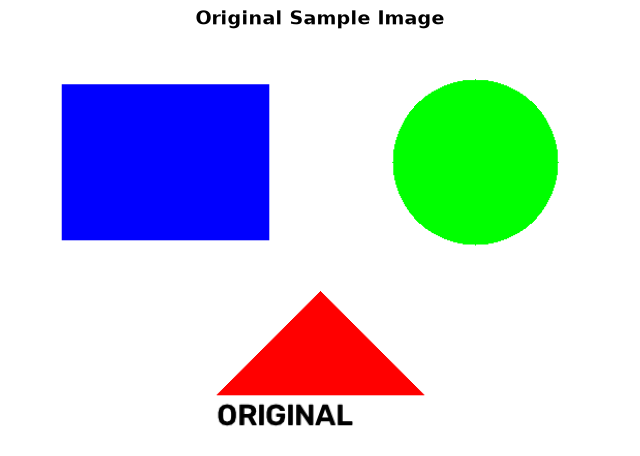

📐 Image dimensions: 600 x 400 pixels (width x height)


In [3]:
# ============================================
# CREATE A SAMPLE IMAGE WITH SHAPES
# ============================================

# Create a blank white canvas (400 height x 600 width x 3 color channels)
img = np.ones((400, 600, 3), dtype=np.uint8) * 255

# Draw a blue rectangle
# Syntax: cv2.rectangle(image, top_left, bottom_right, color_BGR, thickness)
cv2.rectangle(img, (50, 50), (250, 200), (255, 0, 0), -1)  # -1 = filled

# Draw a green circle
# Syntax: cv2.circle(image, center, radius, color_BGR, thickness)
cv2.circle(img, (450, 125), 80, (0, 255, 0), -1)

# Draw a red triangle
triangle_points = np.array([[300, 250], [400, 350], [200, 350]], np.int32)
cv2.fillPoly(img, [triangle_points], (0, 0, 255))

# Add text label
cv2.putText(img, 'ORIGINAL', (200, 380), 
            cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 2)

# Display the image
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original Sample Image', fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

# Store image dimensions for later use
rows, cols = img.shape[:2]  # height, width
print(f"📐 Image dimensions: {cols} x {rows} pixels (width x height)")

## 🔄 Example 1: Basic Affine Transform

### 🎯 Concept:
To perform an affine transformation, you need:
1. **3 source points** - Where points are NOW in the original image
2. **3 destination points** - Where you WANT them to be
3. OpenCV calculates the transformation matrix automatically
4. Apply the matrix to warp the entire image

### 🔧 Key Functions:
```python
# Step 1: Get transformation matrix
M = cv2.getAffineTransform(src_points, dst_points)

# Step 2: Apply transformation
result = cv2.warpAffine(img, M, (width, height))

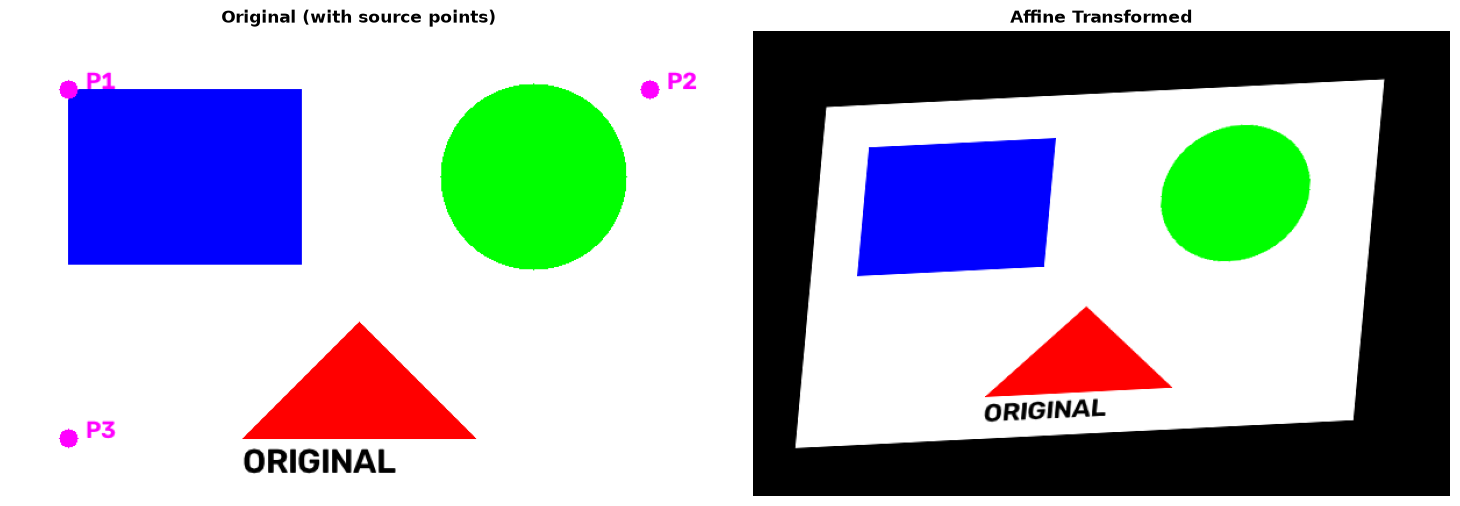

🔢 Transformation Matrix (2x3):
[[ 8.00000000e-01 -6.66666667e-02  6.33333333e+01]
 [-4.00000000e-02  7.33333333e-01  6.53333333e+01]]

This matrix transforms any point (x,y) to its new position (x',y')


In [4]:
# ============================================
# BASIC AFFINE TRANSFORMATION
# ============================================

# Define 3 source points (forming a triangle in the original image)
# These are the corners we're tracking
src_points = np.float32([
    [50, 50],      # Point 1: Top-left area
    [550, 50],     # Point 2: Top-right area
    [50, 350]      # Point 3: Bottom-left area
])

# Define 3 destination points (where we want those points to move)
dst_points = np.float32([
    [100, 100],    # Point 1 moves here (shifted right and down)
    [500, 80],     # Point 2 moves here (shifted left and down)
    [80, 320]      # Point 3 moves here (shifted right and up)
])

# Calculate the affine transformation matrix
# This matrix describes how to transform ANY point in the image
M = cv2.getAffineTransform(src_points, dst_points)

# Apply the transformation to the entire image
transformed = cv2.warpAffine(img, M, (cols, rows))

# Visualize the source points on the original image
img_with_points = img.copy()
for i, point in enumerate(src_points):
    # Draw circles at each source point
    cv2.circle(img_with_points, tuple(point.astype(int)), 8, (255, 0, 255), -1)
    # Label each point
    cv2.putText(img_with_points, f'P{i+1}', 
                (int(point[0])+15, int(point[1])), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 255), 2)

# Display results
show_images([img_with_points, transformed], 
            ['Original (with source points)', 'Affine Transformed'])

print("🔢 Transformation Matrix (2x3):")
print(M)
print("\nThis matrix transforms any point (x,y) to its new position (x',y')")

---

## 🔄 Example 2: Image Rotation (Simple)

### 🎯 Concept:
Rotation is a **special case** of affine transformation!

### 🔧 Function:
```python
cv2.getRotationMatrix2D(center, angle, scale)

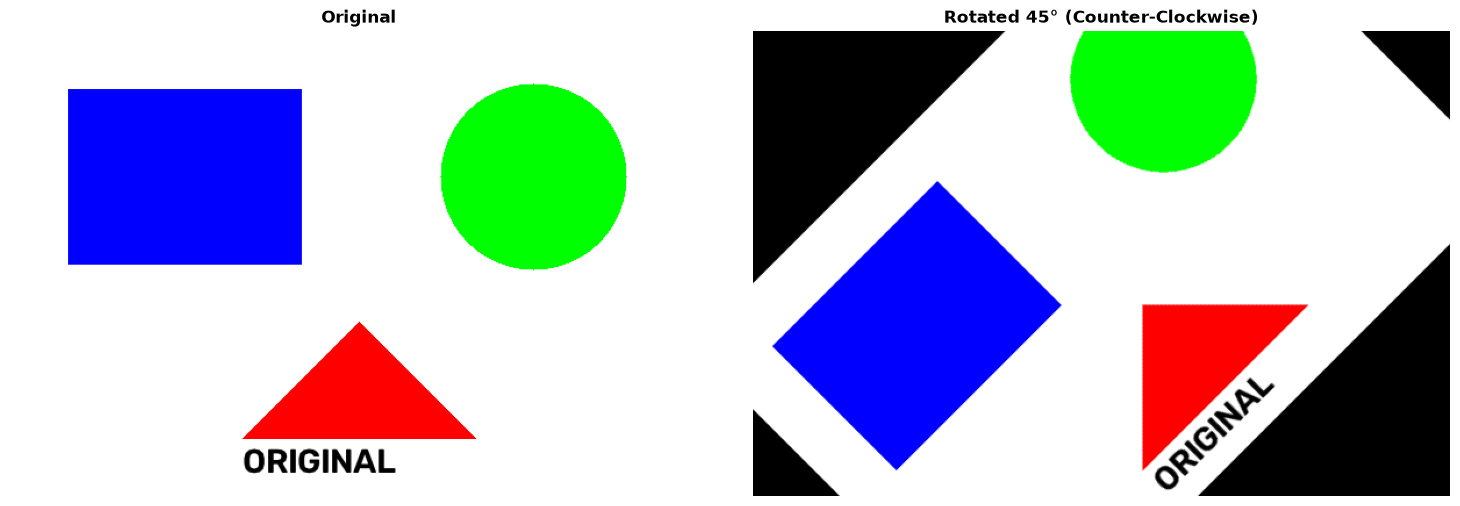

🔄 Rotated 45° around center point (300, 200)
⚠️  Notice: Corners are cropped!

🔢 Rotation Matrix:
[[  0.70710678   0.70710678 -53.55339059]
 [ -0.70710678   0.70710678 270.71067812]]


In [5]:
# ============================================
# SIMPLE ROTATION
# ============================================

# Define rotation parameters
center = (cols // 2, rows // 2)  # Center point of the image
angle = 45                        # Rotate 45 degrees counter-clockwise
scale = 1.0                       # Keep original size (no scaling)

# Get the rotation matrix
# This is a 2x3 affine transformation matrix
M_rotate = cv2.getRotationMatrix2D(center, angle, scale)

# Apply the rotation
rotated = cv2.warpAffine(img, M_rotate, (cols, rows))

# Display results
show_images([img, rotated], 
            ['Original', f'Rotated {angle}° (Counter-Clockwise)'])

print(f"🔄 Rotated {angle}° around center point {center}")
print(f"⚠️  Notice: Corners are cropped!")
print("\n🔢 Rotation Matrix:")
print(M_rotate)


## 🔄 Example 3: Rotation WITHOUT Cropping

### ❌ Problem:
The previous rotation **cut off the corners**!

### ✅ Solution:
1. Calculate how much bigger the canvas needs to be
2. Adjust the transformation matrix to center the rotated image
3. Apply transformation with the new, larger dimensions

### 🧮 Math Behind It:
new_width = (height × |sin(θ)|) + (width × |cos(θ)|)

new_height = (height × |cos(θ)|) + (width × |sin(θ)|)